# Dynamic Two-Asset RR-Style Model

Implements the model in the extension in the written thesis with:

- Firm block: RR-style wedges, static labor demand, dynamic capital with adjustment costs, exogenous death.
- Household: two-asset pricing with SDF \(m_{t,t+1}=\beta u'(C_{t+1})/u'(C_t)\).
- Entry: SDF-discounted free-entry PV condition (with complementarity).
- Distribution \(\mu_t\): survival + deterministic policy transition + entry.
- Aggregation: labor clearing, feasibility, wedge revenue transfers, dividends as residual cashflow.
- Equity: dividends \(D_t\), equity prices \(P_t=m_t(D_{t+1}+P_{t+1})\) (perfect foresight).

The solver is **backward–forward TPI**: firm DP backward (discounted by the SDF), distribution forward, prices/quantities updated until residuals are small.

Note: ChatGPT was used in the development of this notebook.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)


In [2]:
# 1) Utility, SDF, and Euler-implied interest rate

def crra_uprime(C, sigma):
    C = np.maximum(C, 1e-14)
    return C**(-sigma)

def sdf_from_C(C_path, beta, sigma):
    up = crra_uprime(C_path, sigma)
    return beta * up[1:] / up[:-1]

def r_from_C(C_path, beta, sigma, delta):
    C = np.maximum(C_path, 1e-14)
    Rf = (1.0/beta) * (C[1:] / C[:-1])**sigma
    return Rf - 1.0 + delta


In [3]:
# 2) Firm block: static labor, profits, adjustment costs, DP

def labor_demand(s, tau, k, w, alpha, gamma):
    coef = gamma * (1.0 - tau) * s / w
    coef = np.maximum(coef, 1e-14)
    return coef**(1.0/(1.0-gamma)) * k**(alpha/(1.0-gamma))

def output_y(s, k, n, alpha, gamma):
    return s * (k**alpha) * (n**gamma)

def static_profit(s, tau, k, w, r, alpha, gamma, cf):
    n = labor_demand(s, tau, k, w, alpha, gamma)
    y = output_y(s, k, n, alpha, gamma)
    pi = (1.0-gamma) * (1.0-tau) * y - r*k - cf
    return pi, n, y

def adj_cost(i, k, phi_adj):
    return 0.5 * phi_adj * (i**2) / (k + 1e-8)

def firm_dp_backward(w_path, r_path, m_path,
                     sgrid, taugrid, kgrid,
                     alpha, gamma, cf, delta, lam, phi_adj,
                     V_terminal):
    T = len(w_path)
    ns, nt, nk = len(sgrid), len(taugrid), len(kgrid)

    V_next = V_terminal.copy()
    V_path = [None]*(T+1)
    pol_path = [None]*T
    V_path[T] = V_next

    S   = sgrid[:,None,None]
    Tau = taugrid[None,:,None]
    K   = kgrid[None,None,:]

    kp_choices = kgrid[None,None,None,:]   # (1,1,1,nk)
    kcur       = K[:,:,:,None]             # (1,1,nk,1)

    for t in reversed(range(T)):
        w = w_path[t]
        r = r_path[t]
        m = m_path[t]

        pi, _, _ = static_profit(S, Tau, K, w, r, alpha, gamma, cf)

        i   = kp_choices - (1.0-delta)*kcur
        Phi = adj_cost(i, kcur, phi_adj)

        Vn = V_next[:,:,None,:]
        cont = (1.0-lam) * m * Vn

        val = pi[:,:,:,None] - i - Phi + cont

        pol = np.argmax(val, axis=3)
        V   = np.take_along_axis(val, pol[:,:,:,None], axis=3).squeeze(3)

        V_path[t] = V
        pol_path[t] = pol
        V_next = V

    return V_path, pol_path


In [4]:
# 3) Distribution dynamics and aggregation

def pushforward_mu(mu, pol_idx, lam):
    ns, nt, nk = mu.shape
    surv = (1.0 - lam)
    new_mu = np.zeros_like(mu)

    s_idx, t_idx, k_idx = np.indices((ns, nt, nk))
    dest = pol_idx[s_idx, t_idx, k_idx]

    np.add.at(new_mu,
              (s_idx.ravel(), t_idx.ravel(), dest.ravel()),
              (surv * mu).ravel())
    return new_mu

def aggregates(mu, pol_idx, w, r,
               sgrid, taugrid, kgrid,
               alpha, gamma, cf, delta, phi_adj):
    S   = sgrid[:,None,None]
    Tau = taugrid[None,:,None]
    K   = kgrid[None,None,:]

    pi, n, y = static_profit(S, Tau, K, w, r, alpha, gamma, cf)

    N = float(np.sum(mu * n))
    Kagg = float(np.sum(mu * K))
    Y = float(np.sum(mu * (y - cf)))

    kp = np.take_along_axis(kgrid[None,None,:], pol_idx, axis=2)
    i  = kp - (1.0-delta)*K

    Iinc = float(np.sum(mu * i))
    Phi  = float(np.sum(mu * adj_cost(i, K, phi_adj)))

    wedge_rev = float(np.sum(mu * (Tau * y)))

    return {
        "N":N, "K":Kagg, "Y":Y, "Iinc":Iinc, "Phi":Phi, "wedge_rev":wedge_rev,
        "pi":pi, "n":n, "y":y, "kp":kp, "i":i
    }

def dividends(mu, pi, i, kgrid, phi_adj, ce, E):
    K = kgrid[None,None,:]
    Phi = adj_cost(i, K, phi_adj)
    return float(np.sum(mu * (pi - i - Phi)) - ce*E)

def solve_w_labor_clearing(mu, sgrid, taugrid, kgrid, r,
                           alpha, gamma, cf, target_L=1.0,
                           w_bracket=(1e-4, 200.0), tol=1e-10, maxit=100):
    S   = sgrid[:,None,None]
    Tau = taugrid[None,:,None]
    K   = kgrid[None,None,:]

    def N_of_w(w):
        n = labor_demand(S, Tau, K, w, alpha, gamma)
        return float(np.sum(mu * n))

    lo, hi = w_bracket
    f_lo = N_of_w(lo) - target_L
    f_hi = N_of_w(hi) - target_L

    expand = 0
    while f_lo * f_hi > 0 and expand < 20:
        if f_lo > 0 and f_hi > 0:
            hi *= 2.0
            f_hi = N_of_w(hi) - target_L
        else:
            lo /= 2.0
            f_lo = N_of_w(lo) - target_L
        expand += 1

    if f_lo * f_hi > 0:
        return 0.5*(lo+hi), False

    for _ in range(maxit):
        mid = 0.5*(lo+hi)
        f_mid = N_of_w(mid) - target_L
        if abs(f_mid) < tol:
            return mid, True
        if f_lo * f_mid > 0:
            lo, f_lo = mid, f_mid
        else:
            hi, f_hi = mid, f_mid

    return mid, True


In [5]:
# 4) Steady state solver (stationary g)

def firm_vfi_stationary(w, r, beta,
                       sgrid, taugrid, kgrid,
                       alpha, gamma, cf, delta, lam, phi_adj,
                       tol=1e-12, maxit=6000):
    ns, nt, nk = len(sgrid), len(taugrid), len(kgrid)
    V = np.zeros((ns, nt, nk))

    S   = sgrid[:,None,None]
    Tau = taugrid[None,:,None]
    K   = kgrid[None,None,:]
    pi, _, _ = static_profit(S, Tau, K, w, r, alpha, gamma, cf)

    disc = (1.0-lam) * beta

    kp_choices = kgrid[None,None,None,:]
    kcur       = K[:,:,:,None]
    i   = kp_choices - (1.0-delta)*kcur
    Phi = adj_cost(i, kcur, phi_adj)

    for it in range(maxit):
        Vn  = V[:,:,None,:]
        val = pi[:,:,:,None] - i - Phi + disc * Vn
        pol = np.argmax(val, axis=3)
        V_new = np.take_along_axis(val, pol[:,:,:,None], axis=3).squeeze(3)
        err = np.max(np.abs(V_new - V))
        V = V_new
        if err < tol:
            return V, pol, {"it":it, "err":err, "converged":True}

    return V, pol, {"it":maxit, "err":err, "converged":False}

def simulate_mu_stationary(pol, E, g, k0_idx, lam,
                          tol=1e-12, maxit=20000):
    ns, nt = g.shape
    nk = pol.shape[2]

    mu = np.zeros((ns, nt, nk))
    mu[:,:,k0_idx] = (1.0-lam) * E * g / max(lam, 1e-8)

    for it in range(maxit):
        mu_next = pushforward_mu(mu, pol, lam)
        mu_next[:,:,k0_idx] += (1.0-lam) * E * g
        err = np.max(np.abs(mu_next - mu))
        mu = mu_next
        if err < tol:
            return mu, {"it":it, "err":err, "converged":True}

    return mu, {"it":maxit, "err":err, "converged":False}

def solve_steady_state(g, params, grids,
                       w0=1.0, E0=1e-3,
                       maxit=200, tol=1e-6,
                       damp=0.2, entry_kappa=0.8, verbose=True):
    beta=params["beta"]; delta=params["delta"]
    alpha=params["alpha"]; gamma=params["gamma"]
    lam=params["lam"]; cf=params["cf"]; ce=params["ce"]; phi_adj=params["phi_adj"]

    sgrid=grids["s"]; taugrid=grids["tau"]; kgrid=grids["k"]; k0_idx=grids["k0_idx"]

    r = 1.0/beta - 1.0 + delta
    w = float(w0)
    E = float(E0)

    for it in range(maxit):
        V, pol, _ = firm_vfi_stationary(w, r, beta, sgrid, taugrid, kgrid,
                                        alpha, gamma, cf, delta, lam, phi_adj)
        mu, _ = simulate_mu_stationary(pol, E, g, k0_idx, lam)

        w_star, ok = solve_w_labor_clearing(mu, sgrid, taugrid, kgrid, r,
                                            alpha, gamma, cf,
                                            target_L=1.0,
                                            w_bracket=(1e-4, 200.0))
        if ok:
            w_new = w_star
        else:
            w_new = w

        agg = aggregates(mu, pol, w_new, r, sgrid, taugrid, kgrid, alpha, gamma, cf, delta, phi_adj)

        V_entry = float(np.sum(g * V[:,:,k0_idx]))
        PV_entry = (1.0-lam) * beta * V_entry
        gap = PV_entry/ce - 1.0

        E_new = max(0.0, E * np.exp(entry_kappa * gap))

        C = agg["Y"] - agg["Iinc"] - agg["Phi"] - ce*E_new
        C = max(C, 1e-12)

        D = dividends(mu, agg["pi"], agg["i"], kgrid, phi_adj, ce, E_new)

        w = (1.0-damp)*w + damp*w_new
        E = (1.0-damp)*E + damp*E_new

        err = max(abs(agg["N"]-1.0), abs(gap), abs(w_new-w)/max(w,1e-8), abs(E_new-E)/max(E+1e-12,1e-8))
        if verbose and (it % 10 == 0 or it == maxit-1):
            print(f"[SS it {it:03d}] w={w:.6f} r={r:.6f} E={E:.3e} N={agg['N']:.6f} PV/ce={PV_entry/ce:.6f} err={err:.2e}")
        if err < tol:
            break

    transfer = -agg["wedge_rev"]

    return {
        "w":w, "r":r, "E":E, "C":C, "D":D,
        "V":V, "pol":pol, "mu":mu, "agg":agg,
        "V_entry":V_entry, "PV_entry":PV_entry, "transfer":transfer,
        "info":{"it":it}
    }


In [6]:
# 5) Transition (perfect foresight) via TPI

def build_g_path(g_pre, g_post, T, t_reform=0, speed=1.0):
    """Deterministic path for entrant-type distribution g_t."""
    g_path=[]
    for t in range(T):
        if t < t_reform:
            g_path.append(g_pre)
        else:
            x = 1.0 - np.exp(-speed*(t - t_reform))
            g_path.append((1.0-x)*g_pre + x*g_post)
    return g_path


def solve_transition_TPI(
    g_path, ss_pre, ss_post, params, grids,
    T=80, maxit=400, tol=2e-4,
    damp_w=0.25, damp_C=0.15, damp_E=0.25,
    entry_kappa=0.8,
    terminal_lock=0,
    verbose=True,
):
    """
    consistency:
      - Firms solve the DP backward using household SDF m_{t,t+1}.
      - The distribution evolves forward with survival (1-lam) and entry.
      - Aggregates, feasibility, dividends, and residuals are computed using the *same*
        price path used by the DP at each t (no mixing guessed vs implied wages).
      - Wages are *updated* toward the labor-clearing wage, but feasibility uses the
        current guess prices so the iteration is internally coherent.

    Timing convention:
      - r_from_C(C) returns r_{t+1} implied by Euler between C_t and C_{t+1}.
      - We store r_path with length T+1: r_path[0]=r_0, r_path[t+1]=r_{t+1}.
      - Firms at time t take r_t = r_path[t].
    """
    beta=params["beta"]; sigma=params["sigma"]; delta=params["delta"]
    alpha=params["alpha"]; gamma=params["gamma"]
    lam=params["lam"]; cf=params["cf"]; ce=params["ce"]; phi_adj=params["phi_adj"]

    sgrid=grids["s"]; taugrid=grids["tau"]; kgrid=grids["k"]; k0_idx=grids["k0_idx"]
    k0 = float(kgrid[k0_idx])

    # Initial path guesses
   
    w = np.linspace(ss_pre["w"], ss_post["w"], T)
    E = np.linspace(ss_pre["E"], ss_post["E"], T)
    C = np.linspace(ss_pre["C"], ss_post["C"], T+1)

    # Terminal anchoring
    C[-1] = ss_post["C"]
    if terminal_lock > 0:
        C[-terminal_lock:] = ss_post["C"]

    V_T, _, _ = firm_vfi_stationary(
        w=ss_post["w"], r=ss_post["r"], beta=beta,
        sgrid=sgrid, taugrid=taugrid, kgrid=kgrid,
        alpha=alpha, gamma=gamma, cf=cf, delta=delta, lam=lam, phi_adj=phi_adj,
        tol=1e-12, maxit=6000
    )
    P_T = beta/(1.0-beta) * ss_post["D"]

    # TPI iteration
    for it in range(maxit):
        if terminal_lock > 0:
            C[-terminal_lock:] = ss_post["C"]

        m = sdf_from_C(C, beta, sigma) 

        r_next = r_from_C(C, beta, sigma, delta)  # length T

        r_path = np.empty(T+1)
        r_path[0] = ss_pre["r"]
        r_path[1:] = r_next

        V_list, pol_path = firm_dp_backward(
            w_path=w,
            r_path=r_path[:-1],
            m_path=m,
            sgrid=sgrid, taugrid=taugrid, kgrid=kgrid,
            alpha=alpha, gamma=gamma, cf=cf, delta=delta, lam=lam, phi_adj=phi_adj,
            V_terminal=V_T
        )
        V_path = np.stack(V_list, axis=0) if isinstance(V_list, list) else np.asarray(V_list)

        mu_path = np.zeros((T+1, len(sgrid), len(taugrid), len(kgrid)))
        mu_path[0] = ss_pre["mu"]

        D_path = np.zeros(T+1)
        D_path[-1] = ss_post["D"]
        P_path = np.zeros(T+1)
        P_path[-1] = P_T
        Ttransfer = np.zeros(T)

        labor_res = np.zeros(T)
        goods_res = np.zeros(T)
        entry_gap = np.zeros(T)
        cap_law_res = np.zeros(T)

        w_star_path = np.copy(w)
        C_imp_path = np.copy(C)

        Y_path = np.zeros(T)
        K_path = np.zeros(T+1)
        Iinc_path = np.zeros(T)
        Phi_path = np.zeros(T)
        wedge_rev_path = np.zeros(T)

        K_path[0] = float(np.sum(mu_path[0] * kgrid[None,None,:]))

        for t in range(T):
            mu_t = mu_path[t]
            pol_t = pol_path[t]

            w_star, ok = solve_w_labor_clearing(
                mu_t, sgrid, taugrid, kgrid, r_path[t],
                alpha, gamma, cf,
                target_L=1.0,
                w_bracket=(1e-4, 200.0)
            )
            if ok and np.isfinite(w_star):
                w_star_path[t] = w_star
            else:
                w_star_path[t] = w[t]

            agg = aggregates(
                mu_t, pol_t, w[t], r_path[t],
                sgrid, taugrid, kgrid,
                alpha, gamma, cf, delta, phi_adj
            )

            Y_path[t] = agg["Y"]
            Iinc_path[t] = agg["Iinc"]
            Phi_path[t] = agg["Phi"]
            wedge_rev_path[t] = agg["wedge_rev"]

            labor_res[t] = agg["N"] - 1.0

            Ttransfer[t] = -agg["wedge_rev"]

            D_path[t] = dividends(mu_t, agg["pi"], agg["i"], kgrid, phi_adj, ce, E[t])

            C_imp = agg["Y"] - agg["Iinc"] - agg["Phi"] - ce*E[t]
            C_imp = max(float(C_imp), 1e-12)
            C_imp_path[t] = C_imp

            V_entry = float(np.sum(g_path[t] * V_path[t+1][:,:,k0_idx]))
            PV = (1.0-lam) * m[t] * V_entry
            entry_gap[t] = PV/ce - 1.0

            mu_next = pushforward_mu(mu_t, pol_t, lam)
            mu_next[:,:,k0_idx] += (1.0-lam) * E[t] * g_path[t]
            mu_path[t+1] = mu_next

            K_next = float(np.sum(mu_next * kgrid[None,None,:]))
            K_path[t+1] = K_next
            K_implied = (1.0-lam) * float(np.sum(mu_t * agg["kp"])) + (1.0-lam) * E[t] * k0
            cap_law_res[t] = K_next - K_implied

            goods_res[t] = C[t] - C_imp_path[t]

        w = (1.0-damp_w)*w + damp_w*w_star_path

        if terminal_lock > 0:
            up_to = (T+1-terminal_lock)
            C[:up_to] = (1.0-damp_C)*C[:up_to] + damp_C*C_imp_path[:up_to]
            C[-terminal_lock:] = ss_post["C"]
        else:
            C[:T] = (1.0-damp_C)*C[:T] + damp_C*C_imp_path[:T]
            C[-1] = ss_post["C"]

        goods_res = C[:T] - C_imp_path[:T]

        E_new = np.empty_like(E)
        gap_cap = 0.05
        for t in range(T):
            gcap = float(np.clip(entry_gap[t], -gap_cap, gap_cap))
            if (entry_gap[t] < 0.0) and (E[t] < 1e-14):
                E_new[t] = 0.0
            else:
                logE = np.log(max(E[t], 1e-14))
                E_new[t] = float(np.exp(logE + entry_kappa * gcap))
        E = (1.0-damp_E)*E + damp_E*E_new

        P_path[-1] = P_T
        for t in reversed(range(T)):
            P_path[t] = m[t] * (D_path[t+1] + P_path[t+1])

        err = max(
            np.max(np.abs(labor_res)),
            np.max(np.abs(goods_res)),
            np.max(np.abs(entry_gap)),
        )
        if verbose and (it % 10 == 0 or it == maxit-1):
            print(
                f"[TPI it {it:03d}] "
                f"max|labor|={np.max(np.abs(labor_res)):.2e} "
                f"max|goods|={np.max(np.abs(goods_res)):.2e} "
                f"max|entrygap|={np.max(np.abs(entry_gap)):.2e} "
                f"err={err:.2e}"
            )
        if err < tol:
            break

    return {
        "w_t": w,
        "r_t": r_path, 
        "C_t": C, 
        "E_t": E,
        "m_t": np.concatenate((m, [np.nan])),
        "D_t": D_path,
        "P_t": P_path,

        "mu_path": mu_path,
        "V_path": V_path,
        "pol_path": pol_path,

        "labor_res": labor_res,
        "goods_res": goods_res,
        "entry_gap": entry_gap,
        "cap_law_res": cap_law_res,

        "w_star_t": w_star_path,
        "Y_t": Y_path,
        "K_t": K_path,
        "Iinc_t": Iinc_path,
        "Phi_t": Phi_path,
        "wedge_rev_t": wedge_rev_path,
        "Ttransfer_t": Ttransfer,
        "C_imp_t": C_imp_path,
    }


In [7]:
# 6) Baseline calibration + run steady states + transition

params = {
    "beta": 0.96,
    "sigma": 2.0,
    "delta": 0.08,
    "alpha": 0.283,
    "gamma": 0.567,
    "lam": 0.10,
    "cf": 0.00,
    "ce": 1.00,
    "phi_adj": 2.00
}

# Productivity grid (RR 2008): 100 log-spaced points on [1, 3.98]
s_min, s_max, ns = 1.0, 3.98, 100
sgrid = np.logspace(np.log10(s_min), np.log10(s_max), ns)

grids = {
    "s":   sgrid,
    "tau": np.array([0.0, 0.2]),
    "k":   np.linspace(0.05, 6.0, 60),
    "k0_idx": 0
}

ns, nt = len(grids["s"]), len(grids["tau"])

g_pre = np.ones((ns, nt))
g_pre = g_pre / g_pre.sum()

g_post = g_pre.copy()
g_post[2,0] += 0.30
g_post = g_post / g_post.sum()

print("=== Pre-reform steady state ===")
ss_pre = solve_steady_state(g_pre, params, grids, w0=1.0, E0=1e-2,
                            damp=0.35, entry_kappa=0.9, tol=1e-6, maxit=200, verbose=True)

print("\n=== Post-reform steady state ===")
ss_post = solve_steady_state(g_post, params, grids, w0=ss_pre["w"], E0=ss_pre["E"],
                             damp=0.35, entry_kappa=0.9, tol=1e-6, maxit=200, verbose=True)

T = 200
g_path = build_g_path(g_pre, g_post, T=T, t_reform=0, speed=0.20)
print("=== Transition (TPI) ===")
res = solve_transition_TPI(
    g_path, ss_pre, ss_post, params, grids,
    T=T, maxit=600, tol=1e-4,
    damp_w=0.25, damp_C=0.12, damp_E=0.25,
    entry_kappa=0.8,
    terminal_lock=30,
    verbose=True
)
goods_res_post = np.zeros_like(res["goods_res"])
for t in range(len(res["goods_res"])):
    mu_t  = res["mu_path"][t]
    pol_t = res["pol_path"][t]
    w_t   = res["w_t"][t]
    r_t   = res["r_t"][t]
    E_t   = res["E_t"][t]
    C_t   = res["C_t"][t]

    agg = aggregates(
        mu_t, pol_t, w_t, r_t,
        grids["s"], grids["tau"], grids["k"],
        params["alpha"], params["gamma"], params["cf"],
        params["delta"], params["phi_adj"]
    )
    goods_res_post[t] = (C_t + agg["Iinc"] + agg["Phi"] + params["ce"]*E_t) - agg["Y"]

res["goods_res_post"] = goods_res_post
print("Max |goods residual (post recompute)|:", np.max(np.abs(goods_res_post)))


=== Pre-reform steady state ===
[SS it 000] w=0.847601 r=0.121667 E=1.304e+00 N=1.000000 PV/ce=7.572833 err=6.57e+00
[SS it 010] w=25.160345 r=0.121667 E=4.232e+02 N=1.000000 PV/ce=-0.052020 err=1.05e+00
[SS it 020] w=9.158443 r=0.121667 E=3.899e+01 N=1.000000 PV/ce=-0.013903 err=1.01e+00
[SS it 030] w=4.071329 r=0.121667 E=4.120e+00 N=1.000000 PV/ce=0.119406 err=8.81e-01
[SS it 040] w=2.628258 r=0.121667 E=6.978e-01 N=1.000000 PV/ce=0.510946 err=4.89e-01
[SS it 050] w=2.181355 r=0.121667 E=4.296e-01 N=1.000000 PV/ce=1.010361 err=1.04e-02
[SS it 060] w=2.196252 r=0.121667 E=4.417e-01 N=1.000000 PV/ce=0.997705 err=2.30e-03
[SS it 070] w=2.193704 r=0.121667 E=4.406e-01 N=1.000000 PV/ce=1.000848 err=8.48e-04
[SS it 080] w=2.194349 r=0.121667 E=4.406e-01 N=1.000000 PV/ce=0.999791 err=2.09e-04
[SS it 090] w=2.194251 r=0.121667 E=4.407e-01 N=1.000000 PV/ce=1.000026 err=2.64e-05
[SS it 100] w=2.194240 r=0.121667 E=4.407e-01 N=1.000000 PV/ce=1.000008 err=8.23e-06
[SS it 110] w=2.194255 r=0.121

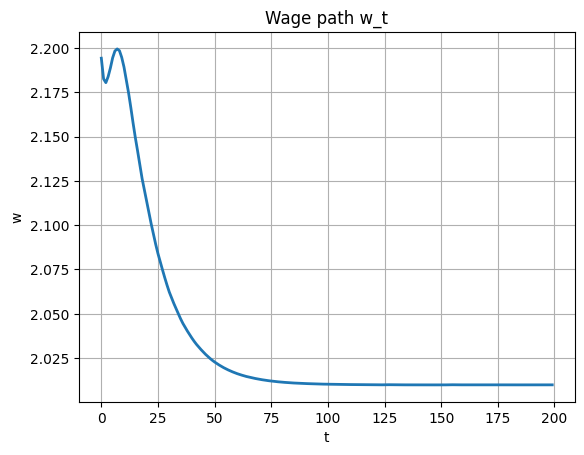

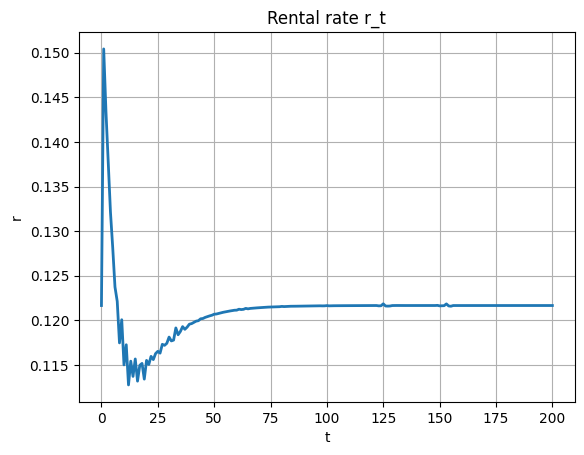

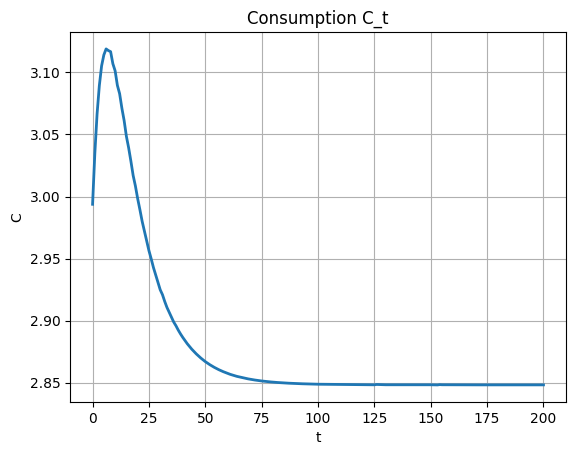

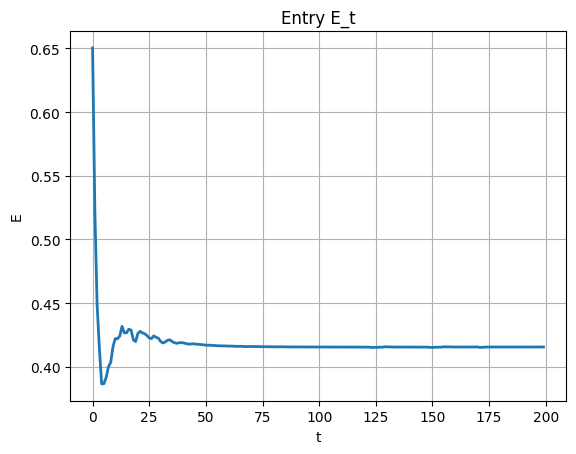

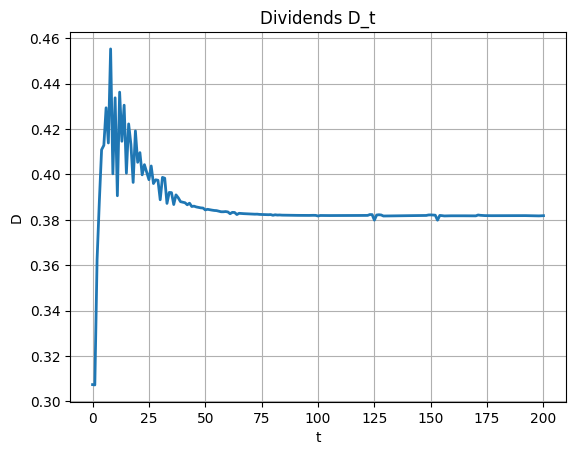

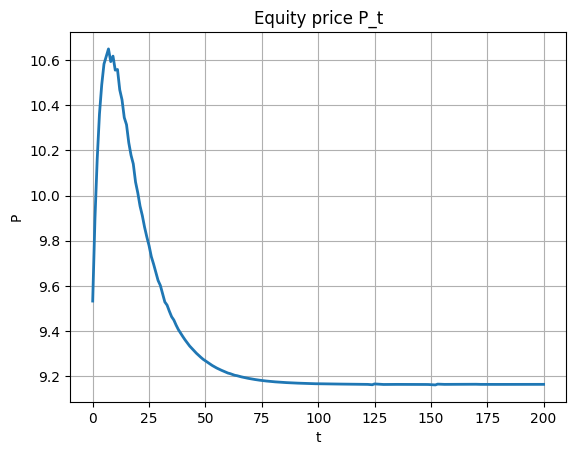

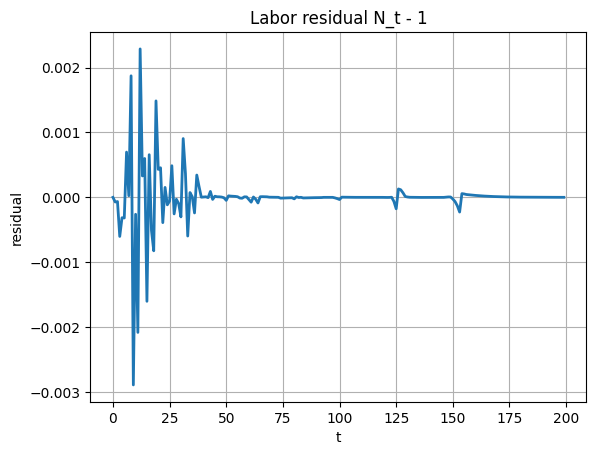

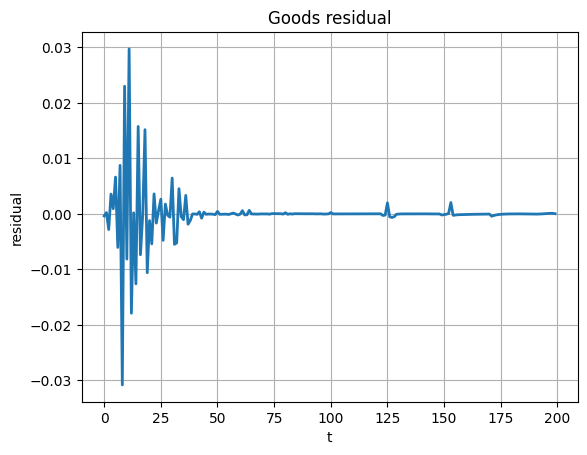

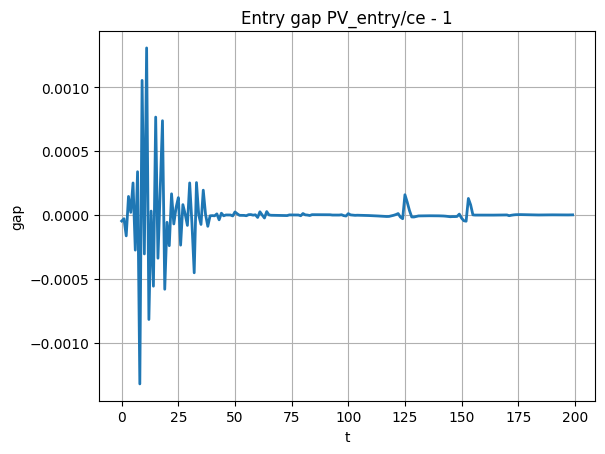

Max |labor residual|: 0.0028896034617863497
Max |goods residual|: 0.030817561703888607
Max |entry gap|     : 0.0013222886130463962


In [8]:
# 7) Plots and diagnostics

def plot_series(x, title, ylabel):
    plt.figure()
    plt.plot(np.arange(len(x)), x, linewidth=2)
    plt.title(title)
    plt.xlabel("t")
    plt.ylabel(ylabel)
    plt.grid(True)

plot_series(res["w_t"], "Wage path w_t", "w")
plot_series(res["r_t"], "Rental rate r_t", "r")
plot_series(res["C_t"], "Consumption C_t", "C")
plot_series(res["E_t"], "Entry E_t", "E")
plot_series(res["D_t"], "Dividends D_t", "D")
plot_series(res["P_t"], "Equity price P_t", "P")

plot_series(res["labor_res"], "Labor residual N_t - 1", "residual")
plot_series(res["goods_res"], "Goods residual", "residual")
plot_series(res["entry_gap"], "Entry gap PV_entry/ce - 1", "gap")

plt.show()

print("Max |labor residual|:", np.max(np.abs(res["labor_res"])))
print("Max |goods residual|:", np.max(np.abs(res["goods_res"])))
print("Max |entry gap|     :", np.max(np.abs(res["entry_gap"])))


In [9]:
# Some plotting

import os
import numpy as np
import matplotlib.pyplot as plt

OUTDIR = "figures_twoasset"
SAVE_PDF = True
SAVE_PNG = True
PNG_DPI = 300

TRIM_TO_T = False
T_PLOT_MAX = None

FIG_W = 7.2 # inches
FIG_H = 4.2

def _apply_pub_rcparams():
    plt.rcParams.update({
        "figure.dpi": 120,
        "savefig.dpi": PNG_DPI,
        "font.size": 11,
        "axes.titlesize": 13,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linewidth": 0.8,
        "lines.linewidth": 2.0,
    })

def _savefig(fig, name):
    base = os.path.join(OUTDIR, name)
    if SAVE_PDF:
        fig.savefig(base + ".pdf", bbox_inches="tight")
    if SAVE_PNG:
        fig.savefig(base + ".png", bbox_inches="tight")
    plt.close(fig)

def _ss_get(ss, key, default=np.nan):
    return ss[key] if (ss is not None and key in ss) else default

def _as1d(x):
    if x is None:
        return None
    a = np.asarray(x).squeeze()
    if a.ndim != 1:
        raise ValueError(f"Expected 1D array, got shape {a.shape}.")
    return a

def _common_n(*arrays):
    lens = []
    for a in arrays:
        if a is None:
            continue
        a1 = _as1d(a)
        lens.append(len(a1))
    if len(lens) == 0:
        raise ValueError("No arrays provided to determine a common length.")
    return int(min(lens))

def _t_and_trim(*arrays, max_T=None):
    """
    Returns (tplot, trimmed_arrays_list).
    - Trims all series to the common minimum length among them.
    - If max_T is provided, also trims to [0..max_T] inclusive.
    """
    n = _common_n(*arrays)
    if max_T is not None:
        n = min(n, int(max_T) + 1)
    tplot = np.arange(n)
    out = []
    for a in arrays:
        if a is None:
            out.append(None)
        else:
            out.append(_as1d(a)[:n])
    return tplot, out

def _to_scalar(x):
    """
    Convert x to a single float if possible.
    - If x is already scalar -> float(x)
    - If x is an array/list with 1 element -> that element
    - Otherwise -> return np.nan (meaning: don't plot SS line)
    """
    if x is None:
        return np.nan
    # numpy scalar
    if np.isscalar(x):
        try:
            return float(x)
        except Exception:
            return np.nan
    # array-like
    try:
        a = np.asarray(x).squeeze()
    except Exception:
        return np.nan
    if a.ndim == 0:
        try:
            return float(a)
        except Exception:
            return np.nan
    if a.size == 1:
        try:
            return float(a.reshape(-1)[0])
        except Exception:
            return np.nan
    # multi-element object: not a scalar SS
    return np.nan

def _add_ss_lines(ax, pre=None, post=None):
    pre_s = _to_scalar(pre)
    post_s = _to_scalar(post)
    if np.isfinite(pre_s):
        ax.axhline(pre_s, linestyle=":", linewidth=1.5)
    if np.isfinite(post_s):
        ax.axhline(post_s, linestyle=":", linewidth=1.5)

os.makedirs(OUTDIR, exist_ok=True)
_apply_pub_rcparams()

maxT = T_PLOT_MAX if TRIM_TO_T else None

w_full = res.get("w_t", None)
r_full = res.get("r_t", None)
C_full = res.get("C_t", None)
E_full = res.get("E_t", None)
D_full = res.get("D_t", None)
P_full = res.get("P_t", None)

goods_res_full = res.get("goods_res", None)
labor_res_full = res.get("labor_res", None)
entry_gap_full  = res.get("entry_gap", None)

w_pre, w_post = _ss_get(ss_pre, "w"), _ss_get(ss_post, "w")
C_pre, C_post = _ss_get(ss_pre, "C"), _ss_get(ss_post, "C")
E_pre, E_post = _ss_get(ss_pre, "E"), _ss_get(ss_post, "E")

D_pre, D_post = _ss_get(ss_pre, "D"), _ss_get(ss_post, "D")
P_pre, P_post = _ss_get(ss_pre, "P"), _ss_get(ss_post, "P")

if not np.isfinite(_to_scalar(P_post)):
    P_post = _ss_get(ss_post, "V")
if not np.isfinite(_to_scalar(P_pre)):
    P_pre = _ss_get(ss_pre, "V")

r_pre, r_post = _ss_get(ss_pre, "r"), _ss_get(ss_post, "r")
if not np.isfinite(_to_scalar(r_post)):
    r_post = (1.0 / float(params["beta"])) - 1.0

if w_full is not None and r_full is not None:
    tplot, (w, r) = _t_and_trim(w_full, r_full, max_T=maxT)

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), constrained_layout=True)
    ax.plot(tplot, w, label=r"$w_t$")
    ax.plot(tplot, r, label=r"$r_t$")
    _add_ss_lines(ax, pre=w_pre, post=w_post)
    _add_ss_lines(ax, pre=r_pre, post=r_post)
    ax.set_title("Factor prices over the transition")
    ax.set_xlabel("Time $t$")
    ax.set_ylabel("Level")
    ax.legend(ncol=2, frameon=False)
    _savefig(fig, "prices_w_r")
else:
    print("Skipping Plot 1 (prices): missing res['w_t'] or res['r_t'].")

series = []
labels = []
ss_pre_lines = []
ss_post_lines = []

if C_full is not None:
    series.append(C_full); labels.append(r"$C_t$")
    ss_pre_lines.append(C_pre); ss_post_lines.append(C_post)
if P_full is not None:
    series.append(P_full); labels.append(r"$P_t$")
    ss_pre_lines.append(P_pre); ss_post_lines.append(P_post)
if D_full is not None:
    series.append(D_full); labels.append(r"$D_t$")
    ss_pre_lines.append(D_pre); ss_post_lines.append(D_post)

if len(series) >= 1:
    tplot, trimmed = _t_and_trim(*series, max_T=maxT)

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), constrained_layout=True)
    for y, lab in zip(trimmed, labels):
        ax.plot(tplot, y, label=lab)
    for pre_line, post_line in zip(ss_pre_lines, ss_post_lines):
        _add_ss_lines(ax, pre=pre_line, post=post_line)

    ax.set_title("Consumption, equity price, and dividends")
    ax.set_xlabel("Time $t$")
    ax.set_ylabel("Level")
    ax.legend(ncol=min(3, len(labels)), frameon=False)
    _savefig(fig, "C_P_D")
else:
    print("Skipping Plot 2 (C,P,D): none of res['C_t'], res['P_t'], res['D_t'] found.")

if E_full is not None:
    tplot, (E,) = _t_and_trim(E_full, max_T=maxT)

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), constrained_layout=True)
    ax.plot(tplot, E, label=r"$E_t$")
    _add_ss_lines(ax, pre=E_pre, post=E_post)
    ax.set_title("Entry over the transition")
    ax.set_xlabel("Time $t$")
    ax.set_ylabel("Level")
    ax.legend(frameon=False)
    _savefig(fig, "entry_E")
else:
    print("Skipping Plot 3 (entry E): missing res['E_t'].")

if entry_gap_full is not None:
    tplot, (entry_gap,) = _t_and_trim(entry_gap_full, max_T=maxT)

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), constrained_layout=True)
    ax.plot(tplot, entry_gap, label="entry gap")
    ax.axhline(0.0, linewidth=1.2)
    ax.set_title("Free-entry condition gap (should be near 0)")
    ax.set_xlabel("Time $t$")
    ax.set_ylabel("Gap")
    ax.legend(frameon=False)
    _savefig(fig, "entry_gap")
else:
    print("Skipping Plot 4 (entry gap): missing res['entry_gap'].")

if goods_res_full is not None:
    tplot, (goods_res,) = _t_and_trim(goods_res_full, max_T=maxT)

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), constrained_layout=True)
    ax.plot(tplot, goods_res, label="goods residual")
    ax.axhline(0.0, linewidth=1.2)
    ax.set_title("Goods market residual (should be near 0)")
    ax.set_xlabel("Time $t$")
    ax.set_ylabel("Residual")
    ax.legend(frameon=False)
    _savefig(fig, "goods_residual")
else:
    print("Skipping Plot 5a (goods residual): missing res['goods_res'].")

if labor_res_full is not None:
    tplot, (labor_res,) = _t_and_trim(labor_res_full, max_T=maxT)

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), constrained_layout=True)
    ax.plot(tplot, labor_res, label="labor residual")
    ax.axhline(0.0, linewidth=1.2)
    ax.set_title("Labor market residual (should be near 0)")
    ax.set_xlabel("Time $t$")
    ax.set_ylabel("Residual")
    ax.legend(frameon=False)
    _savefig(fig, "labor_residual")
else:
    print("Skipping Plot 5b (labor residual): missing res['labor_res'].")

eps = 1e-12
def _reldev(x, xstar):
    x = np.asarray(x)
    return (x - xstar) / (np.abs(xstar) + eps)

norm_items = []
w_post_s = _to_scalar(w_post)
r_post_s = _to_scalar(r_post)
C_post_s = _to_scalar(C_post)
P_post_s = _to_scalar(P_post)
D_post_s = _to_scalar(D_post)
E_post_s = _to_scalar(E_post)

if w_full is not None and np.isfinite(w_post_s):
    norm_items.append((w_full, w_post_s, r"$(w_t-w^\ast)/|w^\ast|$"))
if r_full is not None and np.isfinite(r_post_s):
    norm_items.append((r_full, r_post_s, r"$(r_t-r^\ast)/|r^\ast|$"))
if C_full is not None and np.isfinite(C_post_s):
    norm_items.append((C_full, C_post_s, r"$(C_t-C^\ast)/|C^\ast|$"))
if P_full is not None and np.isfinite(P_post_s):
    norm_items.append((P_full, P_post_s, r"$(P_t-P^\ast)/|P^\ast|$"))
if D_full is not None and np.isfinite(D_post_s):
    norm_items.append((D_full, D_post_s, r"$(D_t-D^\ast)/|D^\ast|$"))
if E_full is not None and np.isfinite(E_post_s):
    norm_items.append((E_full, E_post_s, r"$(E_t-E^\ast)/|E^\ast|$"))

if len(norm_items) >= 1:
    series_only = [it[0] for it in norm_items]
    tplot, trimmed_series = _t_and_trim(*series_only, max_T=maxT)

    fig, ax = plt.subplots(figsize=(FIG_W, FIG_H), constrained_layout=True)
    for (_, xstar, lab), y in zip(norm_items, trimmed_series):
        ax.plot(tplot, _reldev(y, xstar), label=lab)

    ax.set_title("Normalized deviations from post-reform steady state")
    ax.set_xlabel("Time $t$")
    ax.set_ylabel("Relative deviation")
    ax.legend(ncol=2, frameon=False)
    _savefig(fig, "normalized_deviations_to_post_ss")
else:
    print("Skipping Plot 6 (normalized deviations): insufficient SS info or missing series.")

print(f"Saved publication-quality figures to: {OUTDIR}/")
if TRIM_TO_T:
    print(f"NOTE: TRIM_TO_T=True, plots restricted to t ∈ [0, {T_PLOT_MAX}].")


Saved publication-quality figures to: figures_twoasset/


In [10]:
# Diagnostic

import numpy as np

goods_res = res["goods_res"]
t_star = int(np.argmax(np.abs(goods_res)))
print("\n=== GOODS-RESIDUAL DIAGNOSTIC ===")
print(f"Max goods residual occurs at t = {t_star}")
print(f"goods_res[t*] = {goods_res[t_star]:.6e}")

mu_t  = res["mu_path"][t_star]
pol_t = res["pol_path"][t_star]

w_t   = res["w_t"][t_star]
r_t   = res["r_t"][t_star]
E_t   = res["E_t"][t_star]
C_t   = res["C_t"][t_star]

agg = aggregates(
    mu_t, pol_t, w_t, r_t,
    grids["s"], grids["tau"], grids["k"],
    params["alpha"], params["gamma"], params["cf"],
    params["delta"], params["phi_adj"]
)

Y_t    = agg["Y"]
Iinc_t = agg["Iinc"]
Phi_t  = agg["Phi"]

C_imp_t = Y_t - Iinc_t - Phi_t - params["ce"] * E_t

print("\n--- Components at t* ---")
print(f"Y[t*]      = {Y_t:.6e}")
print(f"I_inc[t*]  = {Iinc_t:.6e}")
print(f"Phi[t*]    = {Phi_t:.6e}")
print(f"E[t*]      = {E_t:.6e}")
print(f"C_guess[t*]   = {C_t:.6e}")
print(f"C_implied[t*] = {C_imp_t:.6e}")

print("\n--- Resource constraint check ---")
lhs = C_t + Iinc_t + Phi_t + params["ce"] * E_t
print(f"LHS = C + I + Phi + ce*E = {lhs:.6e}")
print(f"RHS = Y                 = {Y_t:.6e}")
print(f"LHS - RHS               = {lhs - Y_t:.6e}")
print("\n====================================================================")



=== GOODS-RESIDUAL DIAGNOSTIC ===
Max goods residual occurs at t = 8
goods_res[t*] = -3.081756e-02

--- Components at t* ---
Y[t*]      = 4.114137e+00
I_inc[t*]  = 4.014784e-01
Phi[t*]    = 1.625597e-01
E[t*]      = 4.035080e-01
C_guess[t*]   = 3.116758e+00
C_implied[t*] = 3.146591e+00

--- Resource constraint check ---
LHS = C + I + Phi + ce*E = 4.084304e+00
RHS = Y                 = 4.114137e+00
LHS - RHS               = -2.983289e-02



In [11]:
# More diagnostics

import numpy as np
import matplotlib.pyplot as plt

needed = ["w_t", "E_t", "C_t", "r_t", "mu_path", "pol_path", "labor_res", "goods_res", "entry_gap"]
missing = [k for k in needed if k not in res]
if missing:
    raise KeyError(f"Diagnostics cell: res is missing keys {missing}. Available keys: {list(res.keys())}")

for k in ["s", "tau", "k"]:
    if k not in grids:
        raise KeyError(f"Diagnostics cell: grids is missing '{k}'. Available keys: {list(grids.keys())}")

T = len(res["w_t"])

labor_res = np.asarray(res["labor_res"])
goods_res = np.asarray(res["goods_res"])
entry_gap = np.asarray(res["entry_gap"])

print("=== Invariant summary (from solver) ===")
print(f"Max |labor residual|   = {np.max(np.abs(labor_res)):.3e}")
print(f"Max |goods residual|   = {np.max(np.abs(goods_res)):.3e}")
print(f"Max |entry gap|        = {np.max(np.abs(entry_gap)):.3e}")

t_star = int(np.argmax(np.abs(goods_res)))
print(f"\nWorst solver goods residual at t={t_star}: goods_res={goods_res[t_star]:.6e}")


=== Invariant summary (from solver) ===
Max |labor residual|   = 2.890e-03
Max |goods residual|   = 3.082e-02
Max |entry gap|        = 1.322e-03

Worst solver goods residual at t=8: goods_res=-3.081756e-02


=== First 20 periods of the transition (Output and TFP) ===
 t      Y    TFP
 0 4.1009 3.3024
 1 4.0784 3.3072
 2 4.0741 3.3127
 3 4.0784 3.3163
 4 4.0879 3.3168
 5 4.0985 3.3138
 6 4.1090 3.3076
 7 4.1092 3.2986
 8 4.1141 3.2877
 9 4.0926 3.2769
10 4.0922 3.2666
11 4.0742 3.2566
12 4.0765 3.2475
13 4.0559 3.2392
14 4.0413 3.2316
15 4.0197 3.2247
16 4.0137 3.2178
17 3.9957 3.2119
18 3.9807 3.2066
19 3.9767 3.2017

=== Selected periods for thesis table (Output and TFP) ===
  t      Y    TFP
  0 4.1009 3.3024
  1 4.0784 3.3072
  5 4.0985 3.3138
 10 4.0922 3.2666
 25 3.9059 3.1778
 50 3.7922 3.1419
100 3.7688 3.1352
150 3.7681 3.1349
199 3.7682 3.1350


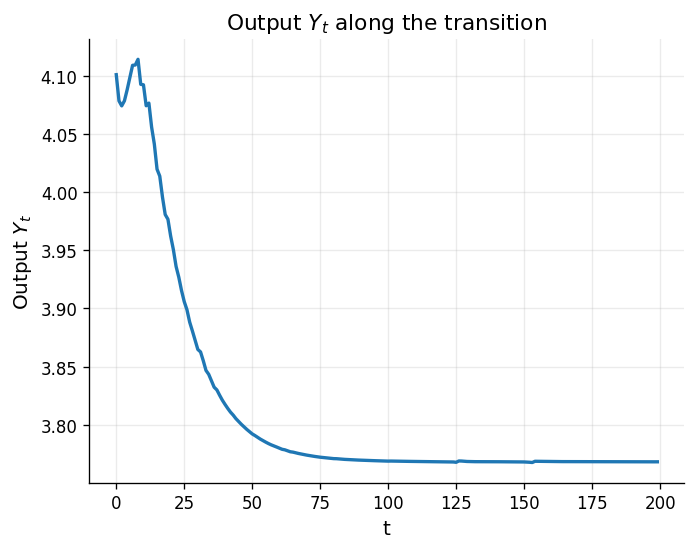

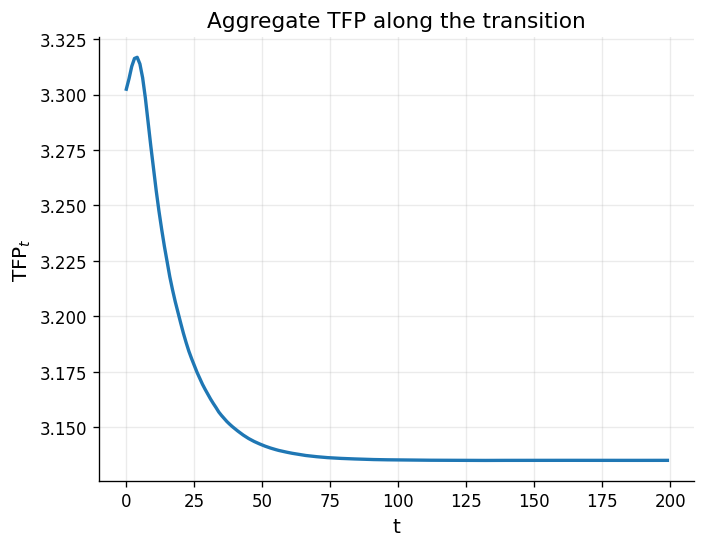

In [ ]:
# More plots, output and TFP table

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

for key in ["mu_path", "pol_path", "w_t", "r_t"]:
    if key not in res:
        raise KeyError(f"Expected '{key}' in res but it is missing. "
                       f"Available keys: {list(res.keys())}")

for key in ["s", "tau", "k"]:
    if key not in grids:
        raise KeyError(f"Expected '{key}' in grids but it is missing. "
                       f"Available keys: {list(grids.keys())}")

alpha = params["alpha"]
gamma = params["gamma"]

T = len(res["w_t"])

Y_path = np.empty(T)
K_path = np.empty(T)
N_path = np.empty(T)

for t in range(T):
    mu_t  = res["mu_path"][t]
    pol_t = res["pol_path"][t]
    w_t   = res["w_t"][t]
    r_t   = res["r_t"][t]

    agg = aggregates(
        mu_t, pol_t, w_t, r_t,
        grids["s"], grids["tau"], grids["k"],
        params["alpha"], params["gamma"], params["cf"],
        params["delta"], params["phi_adj"]
    )
    Y_path[t] = agg["Y"]
    K_path[t] = agg["K"]
    N_path[t] = agg["N"]

eps = 1e-12
TFP_path = Y_path / (
    np.maximum(K_path, eps)**alpha * np.maximum(N_path, eps)**gamma
)

res["Y_recomp_t"] = Y_path
res["TFP_t"]      = TFP_path


df_transition = pd.DataFrame({
    "t":   np.arange(T),
    "Y":   Y_path,
    "TFP": TFP_path
})

print("=== First 20 periods of the transition (Output and TFP) ===")
print(df_transition.head(20).to_string(index=False,
                                       float_format=lambda x: f"{x:0.4f}"))


selected_t = [0, 1, 5, 10, 25, 50, 100, 150, T-1]
selected_t = sorted(set([t for t in selected_t if 0 <= t < T]))

df_selected = df_transition.loc[df_transition["t"].isin(selected_t)].reset_index(drop=True)

print("\n=== Selected periods for thesis table (Output and TFP) ===")
print(df_selected.to_string(index=False,
                            float_format=lambda x: f"{x:0.4f}"))


plt.figure()
plt.plot(df_transition["t"], df_transition["Y"], linewidth=2)
plt.title("Output $Y_t$ along the transition")
plt.xlabel("t")
plt.ylabel("Output $Y_t$")
plt.grid(True)

plt.figure()
plt.plot(df_transition["t"], df_transition["TFP"], linewidth=2)
plt.title("Aggregate TFP along the transition")
plt.xlabel("t")
plt.ylabel("TFP$_t$")
plt.grid(True)

plt.show()

=== Correlated 0.2 wedge experiment: steady states ===
[SS it 000] w=0.858148 r=0.121667 E=1.021e+00 N=1.000000 PV/ce=7.299702 err=6.30e+00
[SS it 010] w=21.614820 r=0.121667 E=2.657e+02 N=1.000000 PV/ce=-0.046476 err=1.05e+00
[SS it 020] w=7.952624 r=0.121667 E=2.493e+01 N=1.000000 PV/ce=0.005498 err=9.95e-01
[SS it 030] w=3.279856 r=0.121667 E=2.836e+00 N=1.000000 PV/ce=0.192246 err=8.08e-01
[SS it 040] w=2.259416 r=0.121667 E=5.708e-01 N=1.000000 PV/ce=0.597442 err=4.03e-01
[SS it 050] w=1.976732 r=0.121667 E=3.749e-01 N=1.000000 PV/ce=0.990042 err=9.96e-03
[SS it 060] w=1.974920 r=0.121667 E=3.766e-01 N=1.000000 PV/ce=1.000782 err=7.82e-04
[SS it 070] w=1.975463 r=0.121667 E=3.768e-01 N=1.000000 PV/ce=1.000024 err=7.15e-05
[SS it 080] w=1.975371 r=0.121667 E=3.767e-01 N=1.000000 PV/ce=0.999949 err=5.92e-05
[SS it 090] w=1.975379 r=0.121667 E=3.767e-01 N=1.000000 PV/ce=0.999949 err=5.15e-05
[SS it 100] w=1.975372 r=0.121667 E=3.767e-01 N=1.000000 PV/ce=0.999959 err=5.22e-05
[SS it 1

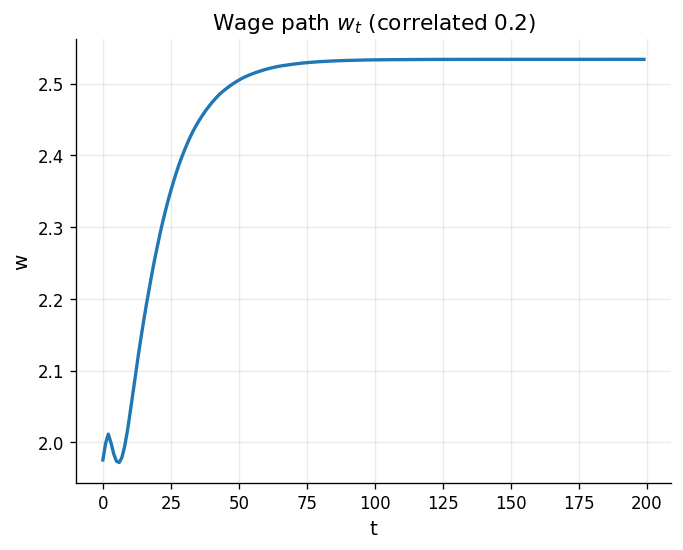

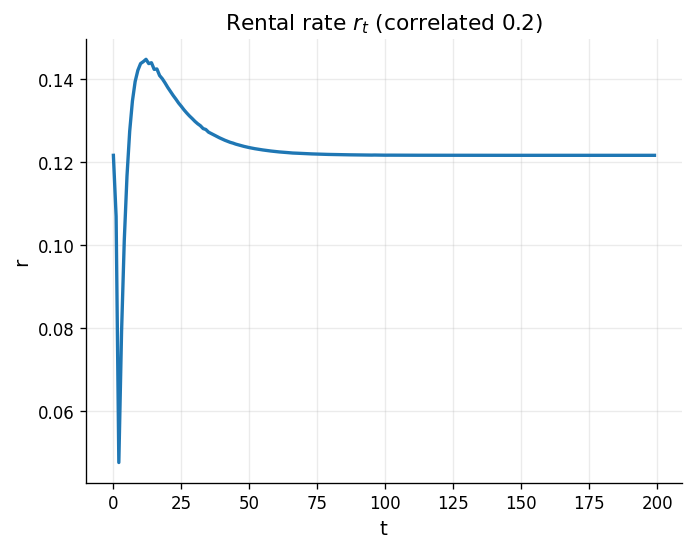

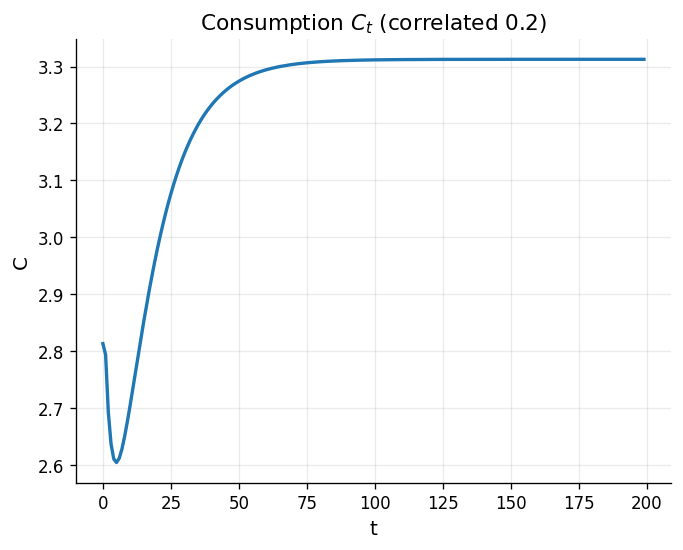

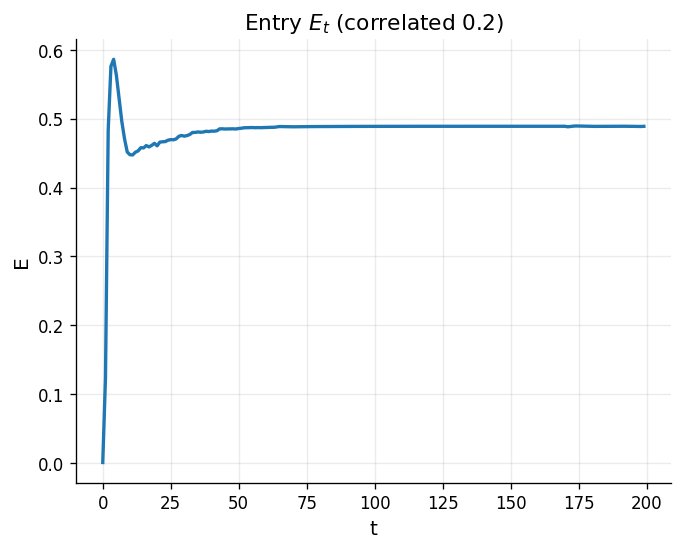

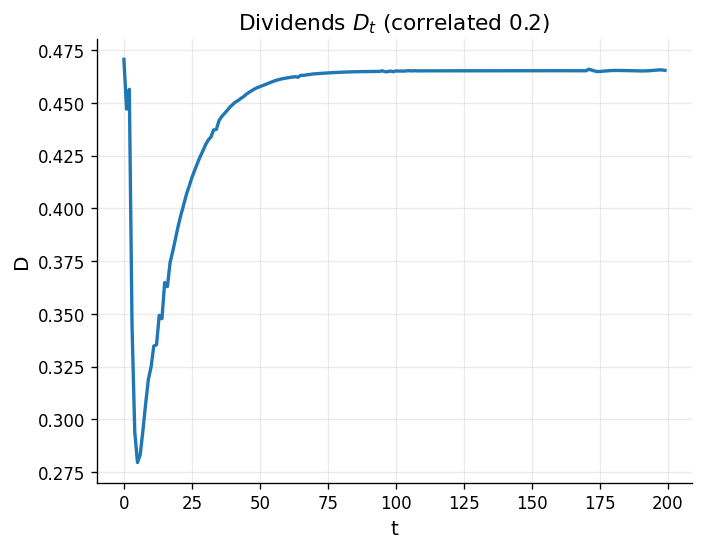

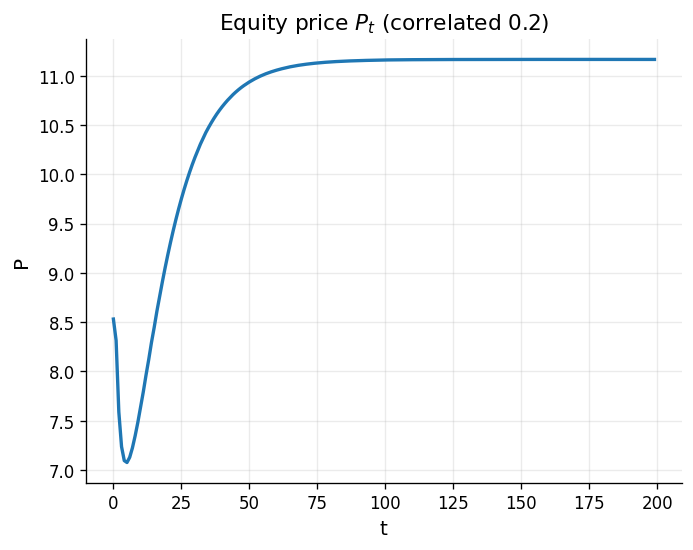

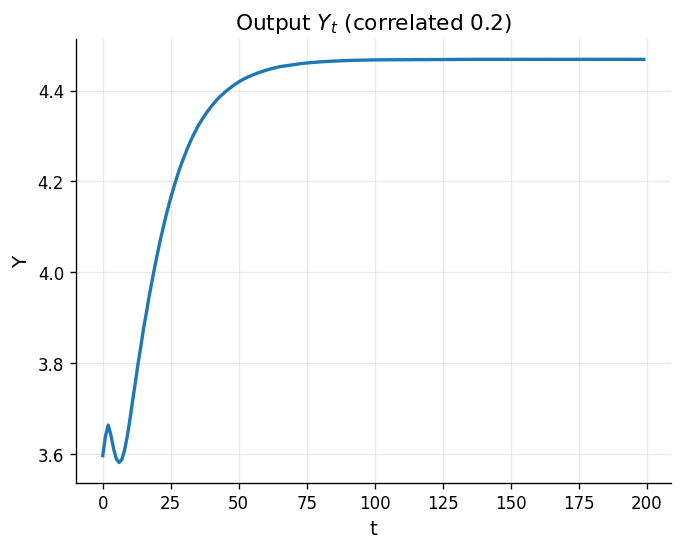

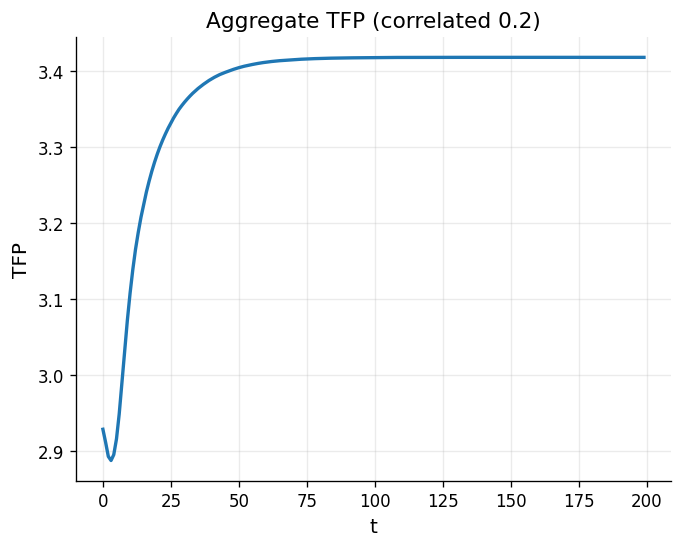

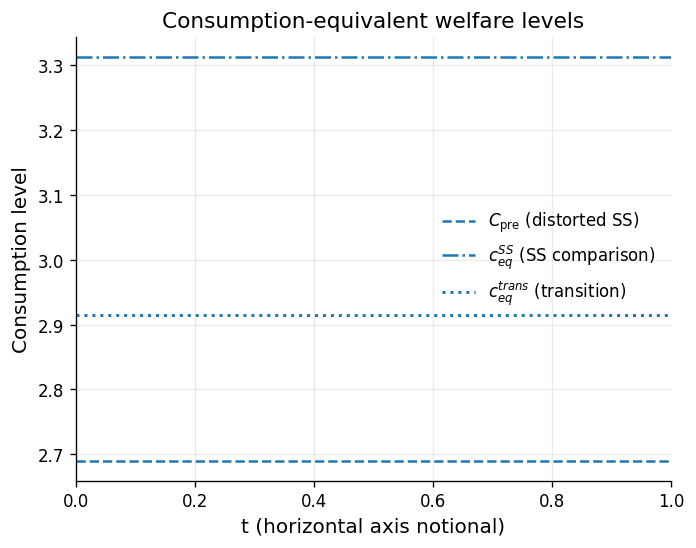

In [ ]:
# Main experiment: 0.2 correlated wedges (RR 2008) with welfare comparison
#
# This cell runs a new transition experiment that mirrors the correlated 0.2 wedge
# case in Restuccia & Rogerson (2008). We start in the distorted correlated
# steady state and then remove the wedges for entrants, letting the economy
# transition to an undistorted steady state. We also compute welfare along the
# transition and compare it to the "pure steady-state" welfare comparison.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    sgrid = grids["s"].copy()
    kgrid = grids["k"].copy()
    k0_idx = int(grids.get("k0_idx", 0))
except NameError:
    s_min, s_max, ns = 1.0, 3.98, 100
    sgrid = np.logspace(np.log10(s_min), np.log10(s_max), ns)
    kgrid = np.linspace(0.05, 6.0, 60)
    k0_idx = 0

ns = len(sgrid)

# RR correlated 0.2 wedge case: high-productivity plants are taxed at tau_t = 0.2,
# low-productivity plants receive a subsidy tau_s chosen in RR so that aggregate
# capital is (approximately) unchanged. In the paper, for tau_t = 0.2, the
# implied subsidy rate is about 0.48 (Table 5).
tau_t = 0.20
tau_s_mag = 0.48
tau_subsidy = -tau_s_mag 
tau_undist  = 0.0

taugrid_exp = np.array([tau_undist, tau_subsidy, tau_t])

grids_corr = {
    "s":   sgrid,
    "tau": taugrid_exp,
    "k":   kgrid,
    "k0_idx": k0_idx,
}


nt = len(taugrid_exp)

g_pre_corr = np.zeros((ns, nt))
mid = ns // 2
g_pre_corr[:mid, 1] = 1.0 
g_pre_corr[mid:, 2] = 1.0 
g_pre_corr /= g_pre_corr.sum()

g_post_corr = np.zeros((ns, nt))
g_post_corr[:, 0] = 1.0
g_post_corr /= g_post_corr.sum()


print("=== Correlated 0.2 wedge experiment: steady states ===")
ss_pre_corr = solve_steady_state(
    g_pre_corr, params, grids_corr,
    w0=1.0, E0=1e-2,
    damp=0.35, entry_kappa=0.9,
    tol=1e-6, maxit=300, verbose=True,
)

ss_post_corr = solve_steady_state(
    g_post_corr, params, grids_corr,
    w0=ss_pre_corr["w"], E0=ss_pre_corr["E"],
    damp=0.35, entry_kappa=0.9,
    tol=1e-6, maxit=300, verbose=True,
)

print("\nPre (distorted) steady state:  C = {:.6f}, Y = {:.6f}, K = {:.6f}".format(
    ss_pre_corr["C"], ss_pre_corr["agg"]["Y"], ss_pre_corr["agg"]["K"]))
print("Post (undistorted) steady state: C = {:.6f}, Y = {:.6f}, K = {:.6f}".format(
    ss_post_corr["C"], ss_post_corr["agg"]["Y"], ss_post_corr["agg"]["K"]))


T_corr = 200 

g_path_corr = build_g_path(
    g_pre_corr, g_post_corr,
    T=T_corr, t_reform=0, speed=0.20,
)

print("\n=== Correlated 0.2 wedge experiment: transition (TPI) ===")
res_corr = solve_transition_TPI(
    g_path_corr, ss_pre_corr, ss_post_corr,
    params, grids_corr,
    T=T_corr, maxit=600, tol=1e-4,
    damp_w=0.25, damp_C=0.12, damp_E=0.25,
    entry_kappa=0.8,
    terminal_lock=30,
    verbose=True,
)

res_final   = res_corr
grids_final = grids_corr


alpha = params["alpha"]
gamma = params["gamma"]

T_sim = len(res_corr["E_t"]) 
Y_corr = np.empty(T_sim)
K_corr = np.empty(T_sim)
N_corr = np.empty(T_sim)

for t in range(T_sim):
    mu_t  = res_corr["mu_path"][t]
    pol_t = res_corr["pol_path"][t]
    w_t   = res_corr["w_t"][t]
    r_t   = res_corr["r_t"][t]

    agg_t = aggregates(
        mu_t, pol_t, w_t, r_t,
        grids_corr["s"], grids_corr["tau"], grids_corr["k"],
        params["alpha"], params["gamma"], params["cf"],
        params["delta"], params["phi_adj"],
    )
    Y_corr[t] = agg_t["Y"]
    K_corr[t] = agg_t["K"]
    N_corr[t] = agg_t["N"]

eps = 1e-12
TFP_corr = Y_corr / (
    np.maximum(K_corr, eps)**alpha * np.maximum(N_corr, eps)**gamma
)

df_transition_corr = pd.DataFrame({
    "t":   np.arange(T_sim),
    "Y":   Y_corr,
    "TFP": TFP_corr,
})

print("\n=== First 20 periods of correlated 0.2 transition (Y and TFP) ===")
print(df_transition_corr.head(20).to_string(
    index=False, float_format=lambda x: f"{x:0.4f}"
))


# Welfare

beta  = params["beta"]
sigma = params["sigma"]

def u_crra(c, sigma):
    c = np.maximum(c, 1e-14)
    if abs(sigma - 1.0) < 1e-10:
        return np.log(c)
    return c**(1.0 - sigma) / (1.0 - sigma)

def utility_constant(C, beta, sigma):
    """Lifetime utility for constant consumption C forever."""
    return u_crra(C, sigma) / (1.0 - beta)

def utility_from_path(C_path, C_terminal, beta, sigma, T_effective=None):
    """
    Discounted utility from a finite transition C_path[0..T-1], followed by
    a constant terminal level C_terminal forever.
    """
    C_path = np.asarray(C_path, dtype=float)
    if T_effective is None:
        T_effective = len(C_path)
    t_idx = np.arange(T_effective, dtype=float)

    U_finite = np.sum((beta**t_idx) * u_crra(C_path[:T_effective], sigma))
    U_tail   = (beta**T_effective) * utility_constant(C_terminal, beta, sigma)
    return U_finite + U_tail

def cons_equiv(U, beta, sigma):
    """
    Consumption level c such that a household with CRRA utility and discount
    factor beta is indifferent between constant c forever and utility U.
    """
    if abs(sigma - 1.0) < 1e-10:
        return np.exp((1.0 - beta) * U)
    factor = (1.0 - sigma) * (1.0 - beta) * U
    factor = np.maximum(factor, 1e-20)
    return factor**(1.0 / (1.0 - sigma))

C_pre  = ss_pre_corr["C"]
C_post = ss_post_corr["C"]

U_pre_SS  = utility_constant(C_pre,  beta, sigma)
U_post_SS = utility_constant(C_post, beta, sigma)


c_eq_SS = cons_equiv(U_post_SS, beta, sigma)
CE_SS   = c_eq_SS / C_pre - 1.0 

C_path_full = np.asarray(res_corr["C_t"], dtype=float)  
C_trans = C_path_full[:T_sim] 
C_term  = C_path_full[T_sim]  

U_trans = utility_from_path(C_trans, C_term, beta, sigma, T_effective=T_sim)
c_eq_trans = cons_equiv(U_trans, beta, sigma)
CE_trans   = c_eq_trans / C_pre - 1.0

print("\n=== Welfare comparison (distorted vs reform) ===")
print(f"Distorted correlated SS consumption C_pre = {C_pre:0.6f}")
print(f"Undistorted SS consumption C_post        = {C_post:0.6f}")
print(f"Pure steady-state comparison:  c_eq_SS / C_pre - 1 = {CE_SS*100:0.4f}%")
print(f"Transition path comparison:   c_eq_trans / C_pre - 1 = {CE_trans*100:0.4f}%")


def plot_series_simple(x, title, ylabel):
    plt.figure()
    plt.plot(np.arange(len(x)), x, linewidth=2)
    plt.title(title)
    plt.xlabel("t")
    plt.ylabel(ylabel)
    plt.grid(True)

plot_series_simple(res_corr["w_t"][:T_sim], "Wage path $w_t$ (correlated 0.2)", "w")
plot_series_simple(res_corr["r_t"][:T_sim], "Rental rate $r_t$ (correlated 0.2)", "r")
plot_series_simple(res_corr["C_t"][:T_sim], "Consumption $C_t$ (correlated 0.2)", "C")
plot_series_simple(res_corr["E_t"],          "Entry $E_t$ (correlated 0.2)", "E")
plot_series_simple(res_corr["D_t"][:T_sim], "Dividends $D_t$ (correlated 0.2)", "D")
plot_series_simple(res_corr["P_t"][:T_sim], "Equity price $P_t$ (correlated 0.2)", "P")

plot_series_simple(Y_corr,   "Output $Y_t$ (correlated 0.2)", "Y")
plot_series_simple(TFP_corr, "Aggregate TFP (correlated 0.2)", "TFP")

plt.figure()
plt.axhline(C_pre,       linestyle="--", linewidth=1.5, label=r"$C_{\mathrm{pre}}$ (distorted SS)")
plt.axhline(c_eq_SS,     linestyle="-.", linewidth=1.5, label=r"$c^{SS}_{eq}$ (SS comparison)")
plt.axhline(c_eq_trans,  linestyle=":",  linewidth=1.8, label=r"$c^{trans}_{eq}$ (transition)")
plt.title("Consumption-equivalent welfare levels")
plt.xlabel("t (horizontal axis notional)")
plt.ylabel("Consumption level")
plt.legend(frameon=False)
plt.grid(True)

plt.show()

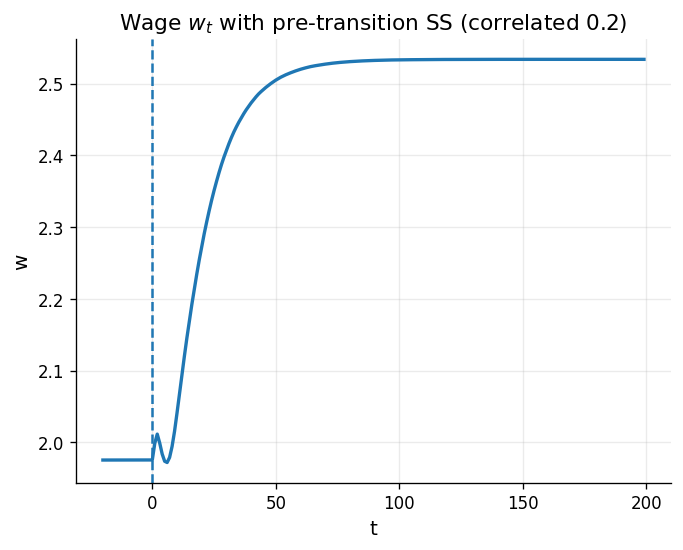

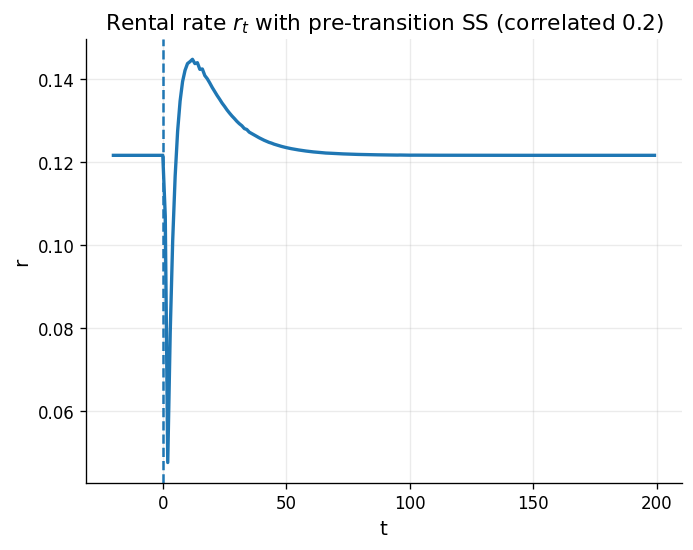

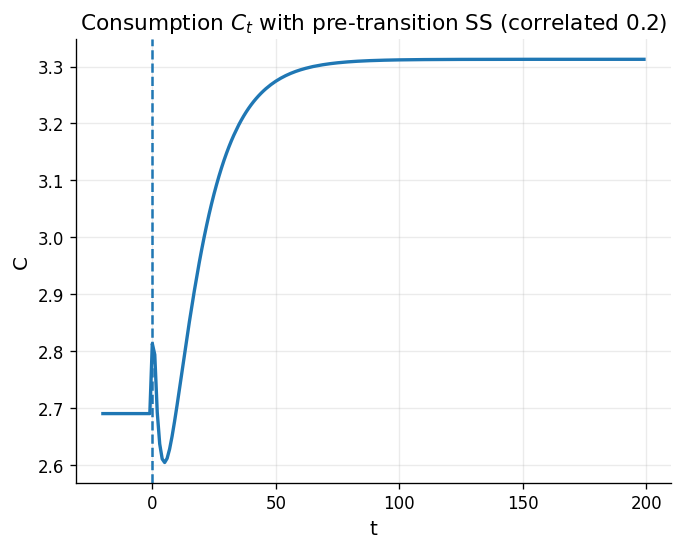

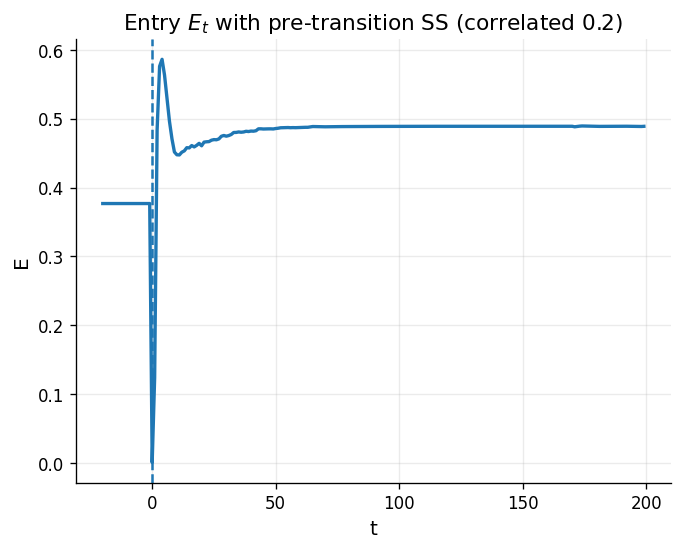

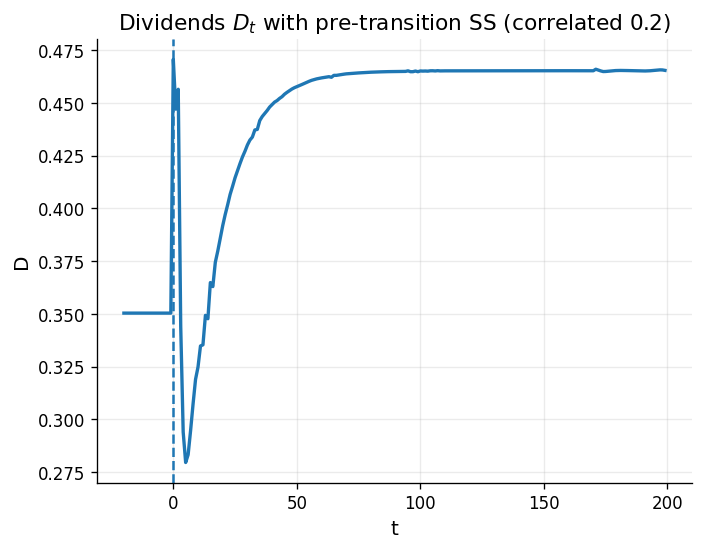

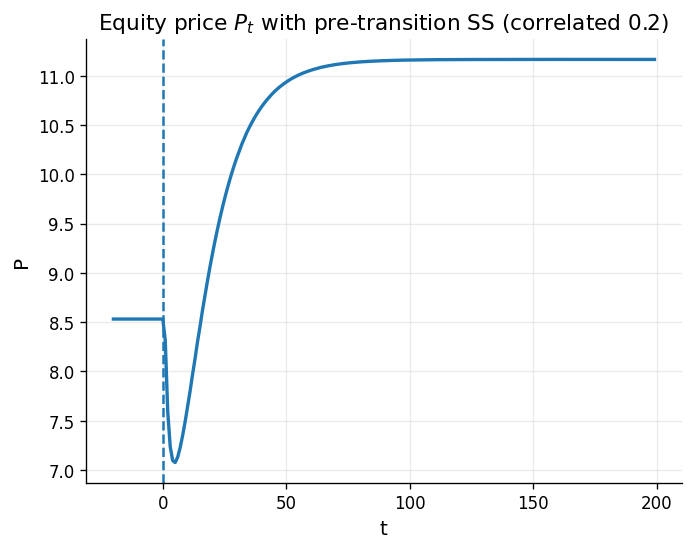

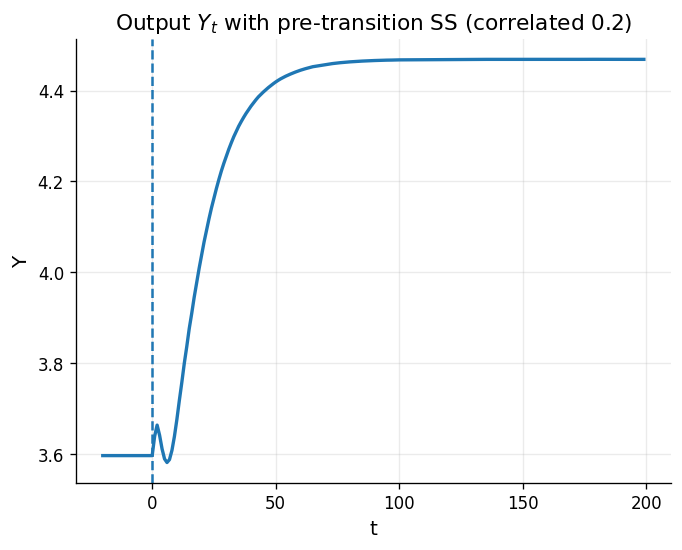

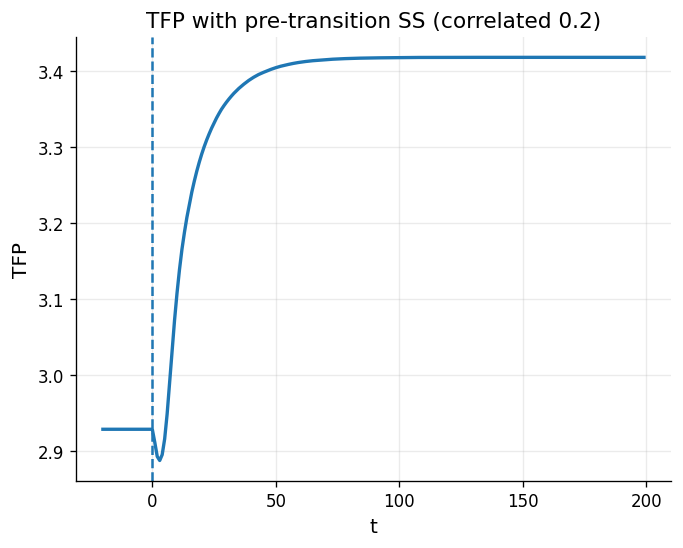

In [ ]:
# Extended Plots with pre-transition periods

import numpy as np
import matplotlib.pyplot as plt

T_pre = 20

try:
    T_sim
except NameError:
    T_sim = len(res_corr["E_t"])

def make_extended_series(x_path, x_ss, T_pre):
    """
    x_path : array-like, length T_sim   (transition path from t=0,...)
    x_ss   : scalar, distorted steady-state value (or approximation)
    T_pre  : int, number of pre-transition periods to show
    """
    x_path = np.asarray(x_path, dtype=float)
    pre = np.full(T_pre, float(x_ss))
    return np.concatenate([pre, x_path])

def plot_series_extended(x_path, x_ss, T_pre, title, ylabel):
    x_ext = make_extended_series(x_path, x_ss, T_pre)
    t_ext = np.arange(-T_pre, len(x_path))
    plt.figure()
    plt.plot(t_ext, x_ext, linewidth=2)
    plt.axvline(0, linestyle="--", linewidth=1.5) 
    plt.title(title)
    plt.xlabel("t")
    plt.ylabel(ylabel)
    plt.grid(True)

w_pre = ss_pre_corr.get("w", res_corr["w_t"][0])
r_pre = ss_pre_corr.get("r", res_corr["r_t"][0])
C_pre = ss_pre_corr.get("C", res_corr["C_t"][0])
E_pre = ss_pre_corr.get("E", res_corr["E_t"][0])

D_pre = ss_pre_corr.get("D", res_corr["D_t"][0])
P_pre = ss_pre_corr.get("P", res_corr["P_t"][0])

plot_series_extended(
    res_corr["w_t"][:T_sim],
    w_pre,
    T_pre,
    "Wage $w_t$ with pre-transition SS (correlated 0.2)",
    "w",
)

plot_series_extended(
    res_corr["r_t"][:T_sim],
    r_pre,
    T_pre,
    "Rental rate $r_t$ with pre-transition SS (correlated 0.2)",
    "r",
)

plot_series_extended(
    res_corr["C_t"][:T_sim],
    C_pre,
    T_pre,
    "Consumption $C_t$ with pre-transition SS (correlated 0.2)",
    "C",
)

plot_series_extended(
    res_corr["E_t"],
    E_pre,
    T_pre,
    "Entry $E_t$ with pre-transition SS (correlated 0.2)",
    "E",
)

plot_series_extended(
    res_corr["D_t"][:T_sim],
    D_pre,
    T_pre,
    "Dividends $D_t$ with pre-transition SS (correlated 0.2)",
    "D",
)

plot_series_extended(
    res_corr["P_t"][:T_sim],
    P_pre,
    T_pre,
    "Equity price $P_t$ with pre-transition SS (correlated 0.2)",
    "P",
)


K_pre = ss_pre_corr["agg"]["K"]
N_pre = ss_pre_corr["agg"]["N"]
Y_pre = ss_pre_corr["agg"]["Y"]

TFP_pre = Y_pre / (np.maximum(K_pre, 1e-12)**alpha * np.maximum(N_pre, 1e-12)**gamma)

plot_series_extended(
    Y_corr,
    Y_pre,
    T_pre,
    "Output $Y_t$ with pre-transition SS (correlated 0.2)",
    "Y",
)

plot_series_extended(
    TFP_corr,
    TFP_pre,
    T_pre,
    "TFP with pre-transition SS (correlated 0.2)",
    "TFP",
)

plt.show()